<a href="https://colab.research.google.com/github/kovurusaisumant95022-netizen/FUTURE_ML_01/blob/main/FUTURE_ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

------------------------------
MODEL EVALUATION RESULTS
Mean Absolute Error: $1821.03
Root Mean Squared Error: $2550.08
------------------------------


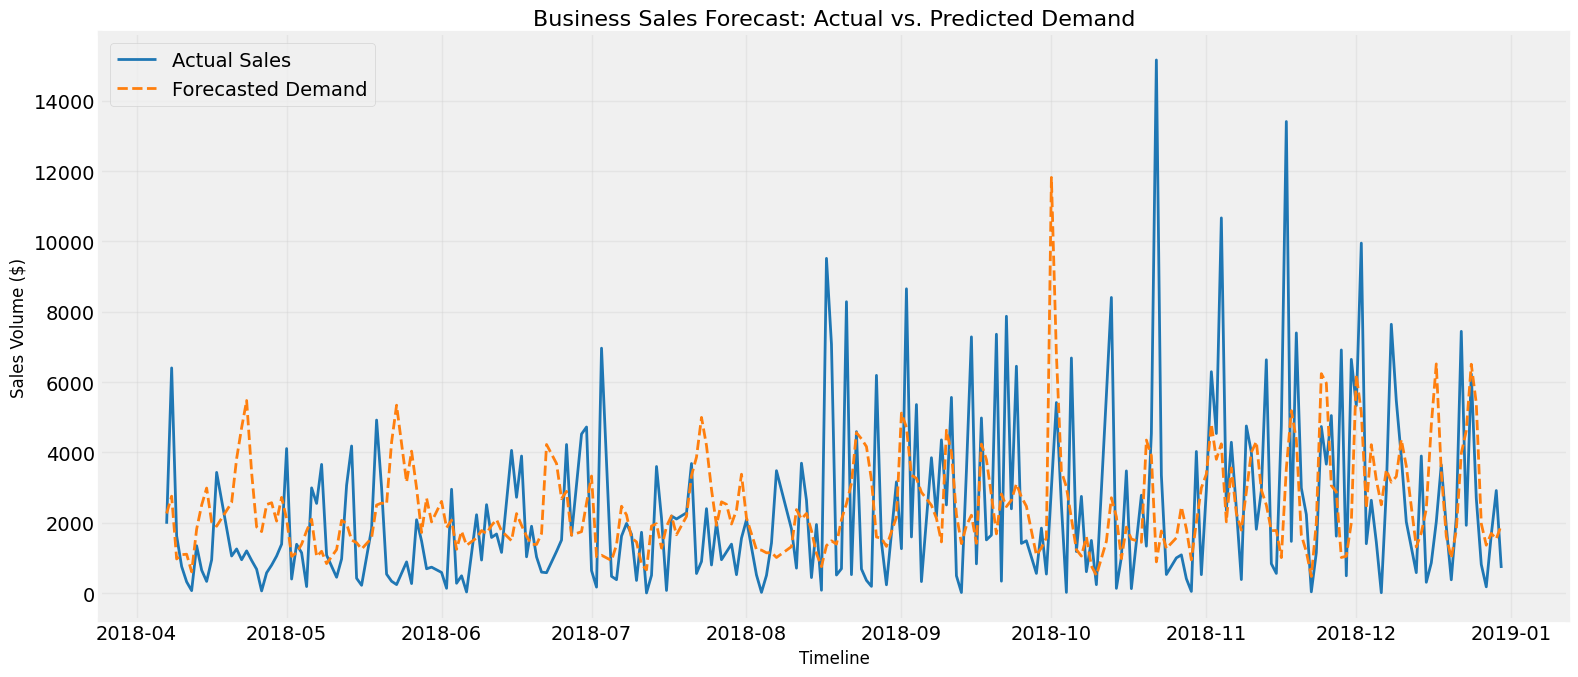


--- Business Planning Note ---
The forecast shows how demand fluctuates based on seasonality (months) and days of the week.
A business manager can use the orange dashed line to plan inventory levels 30-60 days in advance.


In [2]:
# ==========================================
# SALES & DEMAND FORECASTING - COMPLETE CODE
# Project: Future Interns Task 1 (2026)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# 1. LOAD DATA
filename = '/content/train.csv (2).zip'
if not os.path.exists(filename):
    print(f"Error: '{filename}' not found. Please upload the dataset to Colab.")
else:
    df = pd.read_csv(filename)

    # 2. DATA CLEANING & PREPROCESSING
    # Convert 'Order Date' to datetime objects
    df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
    df = df.sort_values('Order Date')

    # Group by date to get daily sales figures
    daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

    # 3. FEATURE ENGINEERING
    # Extract time-based features for the Machine Learning model
    def create_time_features(df):
        df = df.copy()
        df['Year'] = df['Order Date'].dt.year
        df['Month'] = df['Order Date'].dt.month
        df['Day'] = df['Order Date'].dt.day
        df['DayOfWeek'] = df['Order Date'].dt.dayofweek
        return df

    daily_sales = create_time_features(daily_sales)

    # 4. DATA SPLITTING
    # Define features (X) and target variable (y)
    X = daily_sales[['Year', 'Month', 'Day', 'DayOfWeek']]
    y = daily_sales['Sales']

    # Use a non-shuffled split to maintain the time-series order
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # 5. MODEL TRAINING (Random Forest)
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    # 6. EVALUATION
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print("-" * 30)
    print("MODEL EVALUATION RESULTS")
    print(f"Mean Absolute Error: ${mae:.2f}")
    print(f"Root Mean Squared Error: ${rmse:.2f}")
    print("-" * 30)

    # 7. BUSINESS VISUALIZATION
    plt.figure(figsize=(16, 7))
    plt.style.use('fivethirtyeight')

    # Plot actual historical data
    plt.plot(daily_sales['Order Date'][-len(y_test):], y_test,
             label='Actual Sales', color='#1f77b4', linewidth=2)

    # Plot our model's predictions
    plt.plot(daily_sales['Order Date'][-len(y_test):], predictions,
             label='Forecasted Demand', color='#ff7f0e', linestyle='--', linewidth=2)

    plt.title('Business Sales Forecast: Actual vs. Predicted Demand', fontsize=16)
    plt.xlabel('Timeline', fontsize=12)
    plt.ylabel('Sales Volume ($)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 8. BUSINESS INSIGHT OUTPUT
    print("\n--- Business Planning Note ---")
    print("The forecast shows how demand fluctuates based on seasonality (months) and days of the week.")
    print("A business manager can use the orange dashed line to plan inventory levels 30-60 days in advance.")

In [3]:
plt.savefig('sales_forecast_plot.png')
print("Graph saved as 'sales_forecast_plot.png' in your Colab environment.")

Graph saved as 'sales_forecast_plot.png' in your Colab environment.


<Figure size 640x480 with 0 Axes>